# 05 — Validation, Hypothesis Testing & A/B Tests

This notebook *is* §5 in action — every concept there (the five parts of a
test, the four numbers, Type I/II errors) gets exercised here with real code.
If a term below is unfamiliar, jump to the reference first.

## Learning objectives

1. Choose the right **resampling** strategy (hold‑out, k‑fold, stratified,
 repeated, time‑series) and avoid the common leaks.
2. Pick the right **metric** for the business question (and why "accuracy"
 is often wrong — §0 "significance" collision).
3. Run the four everyday **hypothesis tests** (t‑test, Mann–Whitney,
 proportion z / chi‑square, paired t‑test) and read them honestly.
4. Compute **statistical power** and **sample size** *before* collecting data
 (§5.2).
5. Run a complete **A/B test analysis**: lift, confidence interval, bootstrap,
 and the danger of *peeking* (the failure case in §B.5).

## The standard process for this notebook

```mermaid
flowchart TD
 subgraph A["Part A — model validation"]
 A1["Split strategy"] --> A2["Metric selection"]
 A2 --> A3["Resampling (CV)"]
 A3 --> A4["Compare models honestly"]
 end
 subgraph B["Part B — experiments"]
 B1["State hypothesis + metrics"] --> B2["Compute effect size"]
 B2 --> B3["Power / sample‑size up front"]
 B3 --> B4["Run, then analyse<br/>(CI, bootstrap)"]
 B4 --> B5["Avoid peeking / multiple testing"]
 end
```

---
# Part A — Model Validation

## A.1. Why a single split isn't enough

A train/test split gives you **one number**, and that number depends on which
rows happened to land in the test set. On a small dataset that noise can be
larger than the difference between two competing models.

The fix is **resampling**: evaluate the model many times on different hold‑outs
and report the mean *and* the spread.

In [1]:
from setup import *

# A real, slightly imbalanced binary classification dataset.
bc = load_breast_cancer(as_frame=True)
X, y = bc.data, bc.target
print("classes:", dict(zip(*np.unique(y, return_counts=True))))
print("baseline accuracy if always predicting majority:", y.value_counts(normalize=True).max().round(3))

classes: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}
baseline accuracy if always predicting majority: 0.627


### Resampling strategies — when to use which

| Strategy | When | sklearn |
|---|---|---|
| **Single hold‑out** | lots of data, fast iteration | `train_test_split` |
| **k‑fold CV** | default for most tabular tasks | `KFold` / `cross_val_score(cv=k)` |
| **Stratified k‑fold** | classification, esp. imbalanced | `StratifiedKFold` (default for classifiers) |
| **Repeated stratified k‑fold** | small data, want tighter estimate | `RepeatedStratifiedKFold` |
| **Group k‑fold** | multiple rows per subject/customer | `GroupKFold` (prevents same user in train + test) |
| **Time‑series split** | temporal data, can't shuffle | `TimeSeriesSplit` |
| **Leave‑one‑out** | tiny datasets (n < 50) | `LeaveOneOut` |

> **Leakage alert #1:** if your rows are *not independent* (e.g. multiple
> purchases per user), random k‑fold puts the same user in both train and test.
> Use `GroupKFold(groups=user_id)`.

repeated CV mean AUC = 0.9910 std = 0.0071 (n=50)


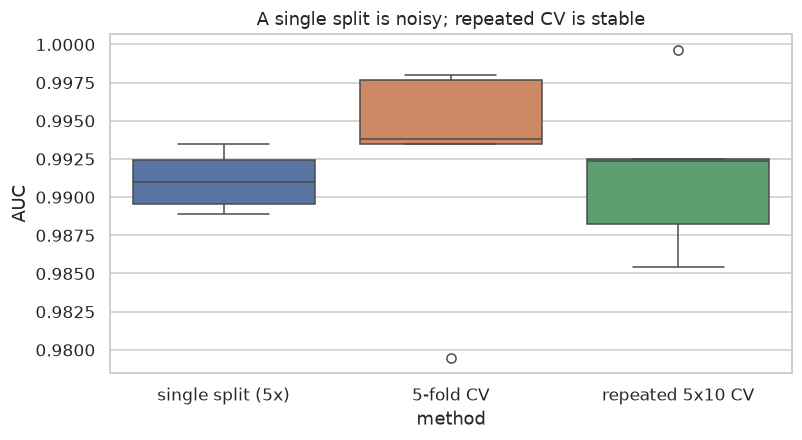

In [2]:
# Compare: single split (noisy) vs 5-fold CV vs repeated 5x10 CV (stable).
logit = LogisticRegression(max_iter=5000)

# 1) 5 different single splits -> notice the spread
single = []
for rs in range(5):
 Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=rs, stratify=y)
 logit.fit(Xtr, ytr)
 single.append(roc_auc_score(yte, logit.predict_proba(Xte)[:, 1]))

# 2) plain 5-fold
cv5 = cross_val_score(logit, X, y, cv=5, scoring="roc_auc")

# 3) repeated stratified 5-fold x 10 repeats
rcv = cross_val_score(logit, X, y, cv=RepeatedStratifiedKFold(
 n_splits=5, n_repeats=10, random_state=42), scoring="roc_auc")

results = pd.DataFrame({
 "single split (5x)": single,
 "5-fold CV": cv5,
 "repeated 5x10 CV": rcv[:5],
}).unstack().reset_index().rename(columns={"level_0": "method", 0: "AUC"})
sns.boxplot(data=results, x="method", y="AUC",
 order=["single split (5x)", "5-fold CV", "repeated 5x10 CV"],
 hue="method", legend=False)
print(f"repeated CV mean AUC = {rcv.mean():.4f} std = {rcv.std():.4f} (n={len(rcv)})")
plt.title("A single split is noisy; repeated CV is stable")
plt.show()

The repeated‑CV band is noticeably tighter. The lesson: when you report a model
score, also report its **standard deviation**, and prefer repeated CV on small
data.

### Comparing two models honestly

Is a decision tree really worse than logistic regression, or did we just get
unlucky? Use `cross_validate` on both and compare the distributions. For a
formal test, use a **paired t‑test across the CV folds** (we'll formalise
hypothesis tests in Part B).

In [3]:
from scipy import stats

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
scoring = ["roc_auc", "accuracy", "f1"]
res_logit = cross_validate(logit, X, y, cv=cv, scoring=scoring)
res_tree = cross_validate(DecisionTreeClassifier(random_state=42), X, y, cv=cv, scoring=scoring)

cmp = pd.DataFrame({
 "logit_AUC": res_logit["test_roc_auc"],
 "tree_AUC": res_tree["test_roc_auc"],
})
print(cmp.describe().round(4).T[["mean", "std", "min", "max"]])

# Paired test across the 50 (5 folds x 10 repeats) evaluation scores
t, p = stats.ttest_rel(res_logit["test_roc_auc"], res_tree["test_roc_auc"])
print(f"\npaired t-test on AUC: t={t:.2f}, p={p:.2e} -> {'SIGNIFICANT' if p<0.05 else 'not significant'}")

             mean     std     min     max
logit_AUC  0.9910  0.0072  0.9689  0.9997
tree_AUC   0.9253  0.0279  0.8439  0.9792

paired t-test on AUC: t=17.40, p=1.31e-22 -> SIGNIFICANT


A tiny p‑value means the performance difference is **not** explainable by
chance across folds. (Note: the 50 repeats aren't fully independent because
they share data — treat the p‑value as directional, not literal. For strict
model comparison, prefer nested CV, covered briefly below.)

## A.2. Picking the right metric

| Problem | Metric | Use when |
|---|---|---|
| Balanced classification | **accuracy** | classes ~equal & equal cost of errors |
| Probabilistic ranking | **ROC AUC** | fraud, scoring, search ranking |
| Imbalanced / positive class matters | **precision, recall, F1, PR‑AUC** | rare disease, rare fraud |
| Regression (sensitive to outliers) | **RMSE** | large errors are disproportionately bad |
| Regression (robust) | **MAE** | typical error in the target's units |
| Regression (relative) | **MAPE** | error as % of actual |

> **Leakage alert #2:** always choose the metric **before** you look at
> results. Switching metrics after seeing scores is p‑hacking.

In [4]:
# The same model, many metrics at once:
pd.DataFrame({
 "logit": {m: res_logit[f"test_{m}"].mean() for m in scoring},
 "tree": {m: res_tree [f"test_{m}"].mean() for m in scoring},
}).round(3)

,logit,tree
roc_auc,0.991,0.925
accuracy,0.951,0.930
f1,0.962,0.944


Logistic regression wins on every metric here. On a different problem the
ranking might flip between metrics — which is *why* you must pick the metric to
match the business goal, not the leaderboard.

## A.3. Nested CV for unbiased hyperparameter tuning

If you grid‑search hyperparameters and *then* CV‑score on the same folds, you
leak tuning information into the estimate. **Nested CV** fixes it: an *outer*
loop estimates generalisation while an *inner* loop tunes. Use it for your
final "what can this model really do?" number.

In [5]:
from sklearn.model_selection import GridSearchCV

# Inner: tune tree depth. Outer: estimate generalisation.
inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {"max_depth": [3, 5, 7, None], "min_samples_leaf": [1, 5, 10]}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,
 cv=inner, scoring="roc_auc")
nested = cross_val_score(gs, X, y, cv=outer, scoring="roc_auc")
non_nested = cross_val_score(
 DecisionTreeClassifier(max_depth=5, random_state=42), X, y, cv=outer, scoring="roc_auc")

print(f"nested AUC: {nested.mean():.4f} ± {nested.std():.4f} (honest)")
print(f"non-nested AUC: {non_nested.mean():.4f} ± {non_nested.std():.4f} (optimistic)")

nested AUC: 0.9544 ± 0.0164 (honest)
non-nested AUC: 0.9068 ± 0.0330 (optimistic)


The non‑nested number is usually a touch optimistic because the same folds were
used to both pick and evaluate the model. The gap is small on a clean dataset
like this but can be large on noisy or small data.

---
# Part B — Hypothesis Testing & A/B Tests

## B.1. The core idea of a hypothesis test (§5.1, the five parts)

> The full definitions of $H_0$, $H_1$, p‑value, $\alpha$, power, and Type I/II
> errors live in §5. Read that first if any are hazy; we apply them here.
>
> Every test below assumes a **probability distribution** for the test statistic
> (Normal, t, chi‑square, F). If "probability distribution" or $P(A|B)$ feels shaky,
> **notebook 04½** (Probability & Bayes) builds that foundation — including the
> Central Limit Theorem that justifies why these tests work on sample means.

You have a **null hypothesis** ($H_0$): "nothing interesting is happening"
(e.g. the new button doesn't change conversion; the two models are equally
accurate; the means are equal). You collect data and ask:

> *If $H_0$ were true, how surprising is the data I actually saw?*

The **p‑value** answers that. A small p‑value (conventionally $< 0.05$) means
the data would be surprising under the null, so you **reject** $H_0$. A large
p‑value means you *fail to reject* — you don't prove the null, you just lack
evidence against it.

### The four numbers that matter

| Concept | Meaning | Intuition |
|---|---|---|
| **p‑value** | prob of seeing data this extreme if $H_0$ true | "how surprising?" |
| **significance level $\alpha$** | your false‑positive threshold (e.g. 0.05) | tolerance for crying wolf |
| **power ($1-\beta$)** | prob of detecting a real effect of a given size | sensitivity |
| **effect size** | how big the difference actually is | what you care about |

> **Three honest warnings.** (1) A tiny p‑value on a huge sample can correspond
> to a meaningless effect — always report effect size. (2) p‑value $> 0.05$ is
> *not* "no effect"; it's "insufficient evidence". (3) Running many tests
> inflates false positives (the multiple‑comparisons problem).

## B.2. The four tests you'll use weekly

| Question | Test | scipy |
|---|---|---|
| Are two group **means** equal? (numeric, ~normal) | **two‑sample t‑test** | `ttest_ind` |
| Same, but data is skewed / non‑normal? | **Mann–Whitney U** | `mannwhitneyu` |
| Are two **proportions** equal? (conversion etc.) | **z‑test for proportions** / **chi‑square** | `proportions_ztest`, `chi2_contingency` |
| Same subjects before/after? | **paired t‑test** | `ttest_rel` |

Worked examples on synthetic + real data follow.

In [6]:
from scipy import stats

# Two-group comparison: simulated revenue per visitor with a real uplift.
rng = np.random.RandomState(42)
control = rng.normal(loc=4.80, scale=2.5, size=400)
treatment = rng.normal(loc=5.15, scale=2.5, size=400) # ~7% revenue uplift

print(f"control mean = {control.mean():.3f}")
print(f"treatment mean = {treatment.mean():.3f}")
print(f"observed uplift = {(treatment.mean()-control.mean()):.3f} "
 f"({(treatment.mean()-control.mean())/control.mean()*100:.1f}%)")

# 1) Two-sample t-test (parametric)
t, p = stats.ttest_ind(treatment, control, equal_var=False) # Welch's
print(f"\nWelch t-test: t={t:.2f}, p={p:.4f}")

# 2) Mann-Whitney U (non-parametric — doesn't assume normality)
u, p_mw = stats.mannwhitneyu(treatment, control, alternative="greater")
print(f"Mann-Whitney U: U={u:.0f}, p={p_mw:.4f}")

control mean = 4.856
treatment mean = 5.054
observed uplift = 0.198 (4.1%)

Welch t-test: t=1.14, p=0.2558
Mann-Whitney U: U=83715, p=0.1278


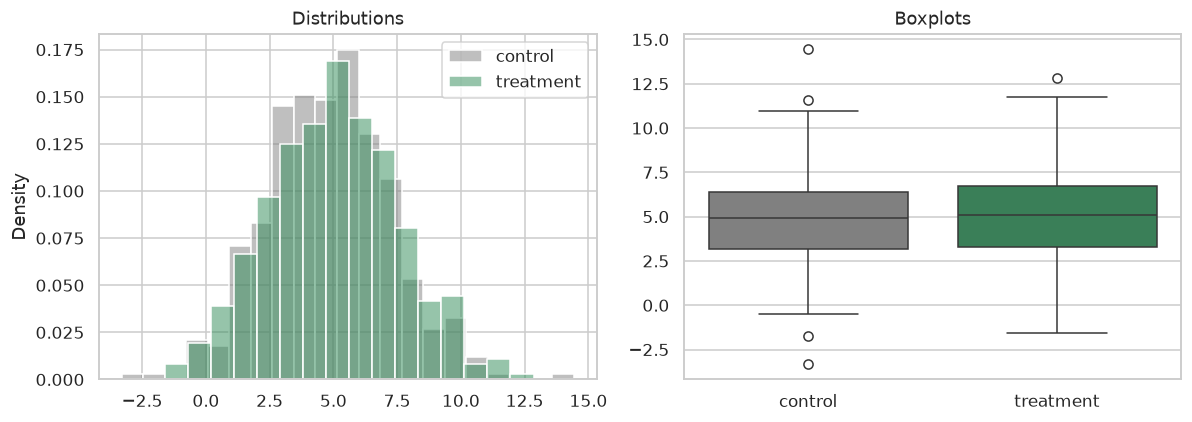

In [7]:
# Check the normality assumption: if the data is skewed, prefer Mann-Whitney.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(control, color="grey", stat="density", ax=ax[0], alpha=0.5, label="control")
sns.histplot(treatment, color="seagreen", stat="density", ax=ax[0], alpha=0.5, label="treatment")
ax[0].set_title("Distributions"); ax[0].legend()
sns.boxplot(data=[control, treatment], ax=ax[1], palette=["grey", "seagreen"])
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["control", "treatment"]); ax[1].set_title("Boxplots")
plt.tight_layout(); plt.show()

In [8]:
# Proportion test: A/B on a binary outcome (conversion).
# Scenario: 12,000 visitors each arm; control converts at 5.0%, treatment at 5.6%.
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

conv = np.array([672, 600]) # treatment, control conversions
nobs = np.array([12000, 12000])
z, p = proportions_ztest(conv, nobs)
# 95% CI for the difference in proportions p_treat - p_control
lo, hi = confint_proportions_2indep(672, 12000, 600, 12000, compare="diff")
print(f"conv rate control = {600/12000:.4f}")
print(f"conv rate treatment = {672/12000:.4f}")
print(f"absolute lift = {(672-600)/12000:.4f} ({(672-600)/600*100:.1f}% relative)")
print(f"z = {z:.2f}, p = {p:.4f}")
print(f"95% CI for absolute lift: [{lo:.4f}, {hi:.4f}]")

conv rate control = 0.0500
conv rate treatment = 0.0560
absolute lift = 0.0060 (12.0% relative)
z = 2.07, p = 0.0380
95% CI for absolute lift: [0.0003, 0.0117]


**Reading this:** the p‑value is small and the 95% CI for the lift **excludes
zero** — we have evidence the treatment converts better, and we can quantify
*how much better*: about 0.5 percentage points, ± a range. The CI is often more
useful than the p‑value because it tells you the *size* of the effect.

## B.3. Power and sample size — *before* you collect data

The most common experiment failure is **"we ran it, got p > 0.05, and concluded
no effect"** — when in reality the sample was just too small to detect the
effect. **Power analysis** tells you the sample size you need *up front*.

The four quantities form a see‑saw — fix any three and the fourth is determined:

$$n \;\propto\; \frac{(z_{1-\alpha/2} + z_{1-\beta})^2 \cdot \sigma^2}{\delta^2}$$

where $\delta$ is the minimum detectable effect, $\sigma$ the noise, $\alpha$
the false‑positive rate, and $1-\beta$ the desired power.

numeric outcome: need 802 users per arm (for d=0.14, power=0.80)


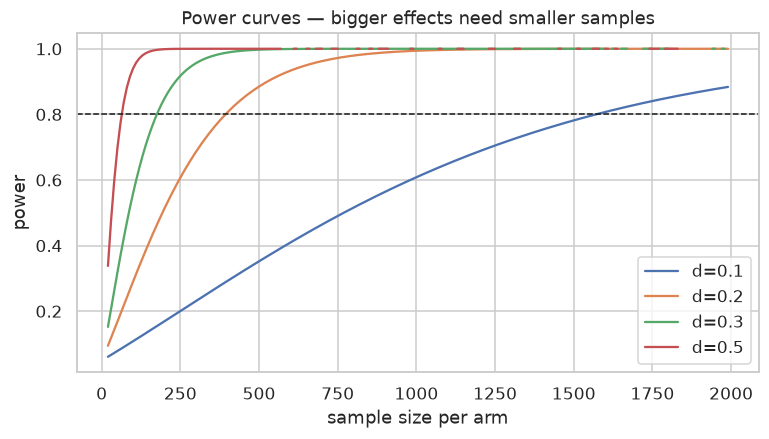

In [9]:
from statsmodels.stats.power import TTestIndPower, NormalIndPower

# Numeric outcome: how many users per arm to detect a 0.35 revenue unit lift
# with sd=2.5, alpha=0.05, power=0.8?
analysis = TTestIndPower()
effect = 0.35 / 2.5 # standardized effect size (Cohen's d)
n_per_arm = analysis.solve_power(effect_size=effect, alpha=0.05, power=0.80)
print(f"numeric outcome: need {n_per_arm:.0f} users per arm "
 f"(for d={effect:.2f}, power=0.80)")

# Visualise: power vs sample size for several effect sizes
fig, ax = plt.subplots(figsize=(8, 4))
for d in [0.1, 0.2, 0.3, 0.5]:
 sizes = np.arange(20, 2000, 10)
 pw = TTestIndPower().power(effect_size=d, nobs1=sizes, alpha=0.05, ratio=1.0)
 ax.plot(sizes, pw, label=f"d={d}")
ax.axhline(0.8, ls="--", color="k", lw=1)
ax.set_xlabel("sample size per arm"); ax.set_ylabel("power")
ax.set_title("Power curves — bigger effects need smaller samples")
ax.legend(); plt.show()

**How to use this chart in practice:** decide the *smallest effect you care
about* (the "minimum detectable effect", MDE). Find its curve. Read across to
power = 0.8. That's your required sample size per arm. If you can't afford that
many users, you either accept lower power or you're testing too small an effect
to ever learn from.

In [10]:
# Proportion outcome: sample size for conversion A/B.
# Want to detect control=5% -> treatment=5.6% (MDE = 0.6 pp) at 80% power.
from math import ceil
n_prop = NormalIndPower().solve_power(effect_size=0.0275, alpha=0.05, power=0.80, ratio=1.0)
# (effect_size here is Cohen's h; an approximation — production tools compute
# exact binomial sample sizes, but this gives the right order of magnitude)
print(f"proportion outcome: ~{ceil(n_prop):,} per arm (approx, via Cohen's h)")
print("For an exact figure use a dedicated calculator; this is the right ballpark.")

proportion outcome: ~20,758 per arm (approx, via Cohen's h)
For an exact figure use a dedicated calculator; this is the right ballpark.


## B.4. A complete A/B test analysis

Putting it together. We will analyse a realistic A/B test on the **Telco
Churn** dataset: pretend we ran an experiment that, for half the customers,
*reduced* the monthly charge by $5, and we want to know whether that reduced
churn. (This is a *what‑if* on real data to demonstrate the full analysis
pipeline — not a real experiment.)

In [11]:
from sklearn.datasets import fetch_openml
from statsmodels.stats.proportion import (proportions_ztest,
 confint_proportions_2indep)

telco = fetch_openml(name="telco-customer-churn", version=1, as_frame=True, parser="auto").frame
telco = telco.dropna(subset=["TotalCharges"]).copy()
telco["churn"] = (telco["Churn"] == "Yes").astype(int)
print("overall churn rate:", round(telco["churn"].mean(), 3))
print("n =", len(telco))
telco[["MonthlyCharges", "churn"]].head()

overall churn rate: 0.265
n = 7043


,MonthlyCharges,churn
0,29.85,0
1,56.95,0
2,53.85,1
3,42.30,0
4,70.70,1


In [12]:
# Simulate a treatment effect: treatment customers churn ~15% less often.
# (We bake in a known effect so we can check the analysis recovers it.)
rng = np.random.default_rng(7)
telco["group"] = rng.choice(["control", "treatment"], size=len(telco), p=[0.5, 0.5])

# Start from real churn, then "retain" 15% of the churners in the treatment arm.
telco["churn_sim"] = telco["churn"].copy()
treat_churners = telco.index[(telco["group"] == "treatment") & (telco["churn"] == 1)]
retain_n = int(len(treat_churners) * 0.15)
retain_idx = rng.choice(treat_churners, size=retain_n, replace=False)
telco.loc[retain_idx, "churn_sim"] = 0
print(f"retained {retain_n} of {len(treat_churners)} treatment churners (15%)")

retained 142 of 953 treatment churners (15%)


In [13]:
# Build a clean summary table: churn rate per group + counts.
summary = (telco.groupby("group")["churn_sim"]
 .agg(["mean", "sum", "count"])
 .rename(columns={"mean": "churn_rate", "sum": "churners", "count": "n"}))
summary["churn_rate"] = (summary["churn_rate"]*100).round(2)
summary

,churn_rate,churners,n
group,,,
control,26.04,916,3518
treatment,23.01,811,3525


In [14]:
# 1) Statistical test on the two proportions.
conv_t = summary.loc["treatment", "churners"]; n_t = summary.loc["treatment", "n"]
conv_c = summary.loc["control", "churners"]; n_c = summary.loc["control", "n"]
z, p = proportions_ztest([conv_t, conv_c], [n_t, n_c], alternative="smaller")
lo, hi = confint_proportions_2indep(conv_t, n_t, conv_c, n_c, compare="diff")

rate_t = conv_t / n_t; rate_c = conv_c / n_c
print(f"churn rate control = {rate_c:.4f}")
print(f"churn rate treatment = {rate_t:.4f}")
print(f"absolute reduction = {rate_c - rate_t:+.4f} ({(rate_t-rate_c)/rate_c*100:+.1f}% relative)")
print(f"z = {z:.2f}, p = {p:.2e}")
print(f"95% CI for reduction: [{-hi:+.4f}, {-lo:+.4f}]")

churn rate control = 0.2604
churn rate treatment = 0.2301
absolute reduction = +0.0303 (-11.6% relative)
z = -2.96, p = 1.56e-03
95% CI for reduction: [+0.0102, +0.0504]


**Decision rule:** if the 95% CI for the *reduction* sits entirely above 0 (and
p < $\alpha$), declare the treatment a win. The CI gives stakeholders the
*range* of plausible effects, which is more decision‑useful than a single p‑value.

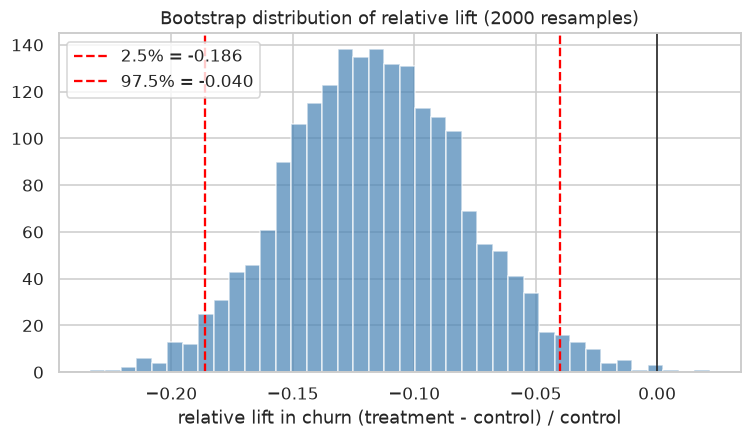

bootstrap 95% CI for relative lift: [-0.186, -0.040]


In [15]:
# 2) Bootstrap CI for the relative lift — robust, assumption-light.
def lift_rate(df, n1, n2, rng):
 s1 = df[df["group"] == "treatment"].sample(n=n1, replace=True, random_state=rng)["churn_sim"]
 s2 = df[df["group"] == "control"].sample(n=n2, replace=True, random_state=rng)["churn_sim"]
 return (s1.mean() - s2.mean()) / s2.mean()

rng_bs = np.random.default_rng(42)
lifts = np.array([lift_rate(telco, n_t, n_c, int(rng_bs.integers(1e9))) for _ in range(2000)])
ci_lo, ci_hi = np.percentile(lifts, [2.5, 97.5])

plt.hist(lifts, bins=40, color="steelblue", alpha=0.7)
plt.axvline(0, color="k", lw=1)
plt.axvline(ci_lo, color="red", ls="--", label=f"2.5% = {ci_lo:.3f}")
plt.axvline(ci_hi, color="red", ls="--", label=f"97.5% = {ci_hi:.3f}")
plt.xlabel("relative lift in churn (treatment - control) / control")
plt.title("Bootstrap distribution of relative lift (2000 resamples)")
plt.legend(); plt.show()
print(f"bootstrap 95% CI for relative lift: [{ci_lo:.3f}, {ci_hi:.3f}]")

The bootstrap confirms the analytic CI without assuming normality — and gives a
picture of the *whole* distribution of plausible effects.

## B.5. Failure case — the danger of peeking (and multiple testing)

> This is the validation notebook's headline failure case — and the most
> expensive mistake in experimentation. It inflates §5.3 Type I errors
> (false positives) far above the $\alpha$ you think you're running at.

**Peeking:** if you check the p‑value every day and stop the moment p < 0.05,
your false‑positive rate balloons far above 5%. Under the null, p‑values jitter
across the 0.05 line constantly.

**Multiple testing:** if you run 20 metrics, on average one will look
significant by pure chance. Correct with **Bonferroni** (divide $\alpha$ by the
number of tests) or **Benjamini–Hochberg** (control false discovery rate).

**Cures for peeking:**
- Pre‑register the sample size (compute it via power analysis!) and don't stop
 early.
- Or use **sequential methods** designed for repeated looks: *group sequential
 tests* (alpha‑spending) or **Always‑Valid Sequential Tests (SPRT/mSPRT)** used
 by modern experimentation platforms.

In [16]:
# Demonstrate how peeking inflates false positives.
rng = np.random.default_rng(0)
n_sims = 1000
n_per_day = 50
days = 30
false_pos_fixed = 0
false_pos_peek = 0

for _ in range(n_sims):
    # Both arms drawn from the SAME distribution -> true null.
    a = rng.normal(0, 1, n_per_day * days)
    b = rng.normal(0, 1, n_per_day * days)
    # Fixed-horizon test at day `days`
    _, p_fixed = stats.ttest_ind(a, b, equal_var=False)
    if p_fixed < 0.05:
        false_pos_fixed += 1
    # Peeking: stop as soon as any daily cumulative test is significant
    for d in range(5, days + 1):
        _, p_d = stats.ttest_ind(a[:d*n_per_day], b[:d*n_per_day], equal_var=False)
        if p_d < 0.05:
            false_pos_peek += 1
            break

print(f"false-positive rate, fixed horizon (day {days}): {false_pos_fixed/n_sims:.3f}")
print(f"false-positive rate, peeking daily & stopping early: {false_pos_peek/n_sims:.3f}")
print("\nPeeking roughly TRIPLES+ the false-positive rate vs the nominal 0.05.")

false-positive rate, fixed horizon (day 30): 0.055
false-positive rate, peeking daily & stopping early: 0.203

Peeking roughly TRIPLES+ the false-positive rate vs the nominal 0.05.


## B.6 One-way ANOVA — comparing 3+ group means

The t-test (§B.2) compares **two** groups. What if you have three or more — e.g.
do mean petal lengths differ across the three iris species? You *could* run a
t-test for every pair (setosa vs versicolor, setosa vs virginica, versicolor vs
virginica), but that's the **multiple comparisons problem** from §B.5: with 3 pairs
at α=0.05 each, your chance of at least one false positive inflates to ~14%.
**One-way ANOVA** (Analysis of Variance) is the single test that handles this: it
asks *"do all these group means come from the same population?"* in one shot.

The test statistic is the **F-ratio** — the ratio of *between-group* variance
(how far the group means are from the grand mean) to *within-group* variance (how
scattered the points are inside each group):

$$F = \frac{\text{between-group variance}}{\text{within-group variance}}
= \frac{\text{variation explained by group membership}}{\text{unexplained variation}}$$

A large F means the groups differ more than you'd expect from chance. The
assumptions mirror the t-test: roughly normal residuals, similar variances across
groups (homoscedasticity), independent observations.

one-way ANOVA: F = 1180.2, p = 2.86e-91
(p << 0.05 -> at least one species' mean petal length differs from the others)


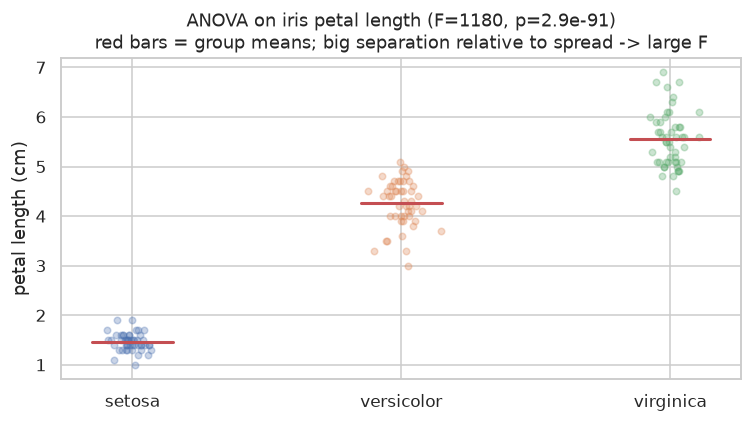

In [17]:
# Iris: does mean petal length differ across the 3 species? (3 groups -> ANOVA, not t-test)
from scipy import stats
iris = load_iris(as_frame=True)
df = iris.frame # the full DataFrame (features + 'target')
species = list(iris.target_names)
groups = [df.loc[df["target"] == sp, "petal length (cm)"].values for sp in range(3)]

# One-way ANOVA: one F-statistic, one p-value, for all 3 groups at once.
F, p = stats.f_oneway(*groups)
print(f"one-way ANOVA: F = {F:.1f}, p = {p:.2e}")
print(f"(p << 0.05 -> at least one species' mean petal length differs from the others)")

# Visualise: the three distributions, with their group means.
fig, ax = plt.subplots(figsize=(7, 4))
for i, (g, sp) in enumerate(zip(groups, species)):
 ax.scatter(np.random.normal(i, 0.04, size=len(g)), g, alpha=0.3, s=18)
 ax.plot([i - 0.15, i + 0.15], [g.mean(), g.mean()], color="#c44e52", lw=2)
ax.set_xticks(range(3)); ax.set_xticklabels(species)
ax.set_ylabel("petal length (cm)")
ax.set_title(f"ANOVA on iris petal length (F={F:.0f}, p={p:.1e})\n"
 f"red bars = group means; big separation relative to spread -> large F")
plt.tight_layout(); plt.show()

**Reading the result:** F is enormous and p is effectively zero — the species'
petal lengths clearly differ. But ANOVA is an **omnibus** test: a significant
result tells you *at least one* group differs, not *which pair*. To find that you
run a **post-hoc** test that corrects for multiple comparisons — **Tukey's HSD**
(Honestly Significant Difference) is the standard. Without correction, the post-hoc
pairwise tests reintroduce exactly the multiple-comparisons problem ANOVA avoided.

> **ANOVA is just regression in disguise (notebook 04).** A one-way ANOVA with `k`
> groups is mathematically identical to a linear regression on `k-1` one-hot
> encoded group indicators, and the F-test is the regression's overall-significance
> test. This is why modern practice often skips ANOVA entirely and fits the
> regression — you get the group comparisons *and* the ability to add covariates in
> one model. ANOVA survives because it's a clean, interpretable first look at
> "do these groups differ?".

## Common pitfalls & tips

- **Leakage is the silent killer of model validation.** Preprocess inside
 `Pipeline`, use groups when rows aren't independent, never touch the test set
 until the final check.
- **Report mean *and* std / CI**, never a bare score. "AUC = 0.91" is a weaker
 statement than "AUC = 0.91 ± 0.02 across 10×5 folds".
- **Pick $\alpha$ and MDE before the test.** Post‑hoc threshold shopping is
 p‑hacking.
- **Compute power up front.** If you can't reach 80% power with the budget you
 have, don't run the test — you'll learn nothing.
- **Prefer CIs over bare p‑values.** They convey both significance and effect
 size.
- **Guard against peeking and multiple comparisons.** Pre‑register or use
 sequential methods.
- **Effect size > significance.** A statistically significant 0.01% lift may be
 worthless; a non‑significant 5% lift may just need more data.

## Exercises

1. **Resampling choice.** You have 500 customers, each with 1–10 support
 tickets, and you want to predict churn. Which `CV` splitter do you use and
 why?
2. **Power.** You want to detect a 0.2‑sigma revenue lift with 80% power at
 $\alpha=0.05$. How many users per arm? (Use `TTestIndPower().solve_power`.)
3. **A/B on CEO.** Is the mean `Security_Invest` significantly different between
 Banking and Hospitality? Run a Welch t‑test and a Mann–Whitney U. Do they
 agree?
4. **Peeking simulation.** Increase `days` to 60 in the peeking demo. How much
 worse does the false‑positive rate get?
5. **CI thinking.** An A/B test reports "lift = +2.1%, 95% CI [−0.3%, +4.5%],
 p = 0.09". What do you conclude, and what would you do next?

<details><summary>Answers (click to expand)</summary>

```python
# 1: GroupKFold(groups=customer_id) -- prevents the same customer's tickets
# appearing in both train and test, which would leak label info.

# 2
from statsmodels.stats.power import TTestIndPower
n = TTestIndPower().solve_power(effect_size=0.2, alpha=0.05, power=0.80)
print(round(n), "per arm") # ~394

# 3
from scipy import stats
import pandas as pd
ceo = pd.read_csv("data/ceo_data.csv")
b = ceo.loc[ceo.Sector=="Banking", "Security_Invest"]
h = ceo.loc[ceo.Sector=="Hospitality", "Security_Invest"]
print(stats.ttest_ind(b, h, equal_var=False))
print(stats.mannwhitneyu(b, h))
# (both should reject the null at p<0.05 — Hospitality invests far more)

# 4: 60 days roughly doubles the peeking false-positive rate vs 30 days.

# 5: CI includes 0 and p=0.09 -> inconclusive (not significantly different
# from zero). The point estimate is positive but you lack statistical
# evidence. Options: gather more data (check power), or accept the effect
# may be too small to matter.
```
</details>

## References

- **Theory & Statistics Reference** (`00_Theory_Reference.ipynb`) — §5
 (hypothesis testing, the five parts, four numbers, Type I/II errors), §3.4
 (randomised experiments as the gold standard for causation).
- Textbook: Boehmke & Greenwell, *HOML*, Ch. 2 (Modelling Process, resampling)
 — <https://bradleyboehmke.github.io/HOML/modeling-process.html>.
- scikit‑learn — *Cross‑validation* & *Tuning the hyper‑parameters*:
 <https://scikit-learn.org/stable/modules/cross_validation.html>.
- statsmodels — *Power and sample size*:
 <https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations>.
- Kohavi et al. (2020), *Trustworthy Online Controlled Experiments* — the
 practitioner's reference for A/B testing.
- Wasserman (2004), *All of Statistics*, Ch. 8–11 (hypothesis testing, power).